In [1]:
!pip install qiskit
!pip install pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 73.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=64e762556de74bb95a46f293ec6006e26a2fcdb8269eb3cd379deafe1ab1f090
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


*Dynamic Circuits* are powerful tools used to measure qubits in the middle of
quantum circuit.

⭐ Dynamic circuits = Measure =>**bold text** Decide => Act

-  **Classical Feedforward:** Based on the results from the dynamic circuits measurement, we perform classical logic operations

-  Some places where Dynamic circuits are used for:
  1. Efficient quantum state preparation like GHZ state, W state and a broad class of matrix product states.
  2. Efficient long range entanglement between qubits on the same chip shallow circuits
  3. Efficient sampling of IQP like circuits





> "if_test" => conditional operator: perform operation if the given condition is met(based on the classical register value).



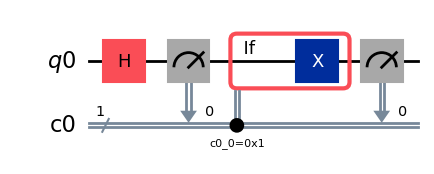

In [2]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit

qr = QuantumRegister(1)
cr = ClassicalRegister(1)
qc = QuantumCircuit(qr, cr)
qc.h(qr[0]) # Applies Hadamard gate
qc.measure(qr[0], cr[0]) # Measure the qubit
with qc.if_test((cr[0], 1)): # If classical bit is 1, then apply X gate
  qc.x(qr[0])
qc.measure(qr[0], cr[0]) # Measure the qubits
qc.draw('mpl')

# Always '0' as output

Since quantum conditions depend on runtime measurement results, we cannot use normal Python **if-else**. Qiskit uses **if_test**, which is a context manager that lets us define conditional blocks using the **with** statement. The **as else_** part gives access to the else branch, which can be defined using another **with** block

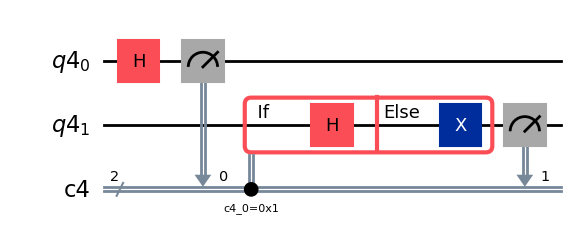

In [6]:
qubits = QuantumRegister(2)
bits = ClassicalRegister(2)
qc = QuantumCircuit(qubits, bits)
qc.h(qubits[0])
qc.measure(qubits[0], bits[0])
with qc.if_test((bits[0], 1)) as else_: # If classical bits[0] is 1 then apply Hadamard gate on qubits[1]
  qc.h(qubits[1])
with else_: # Else apply X gate on qubits[1]
  qc.x(qubits[1])
qc.measure(qubits[1], bits[1])
qc.draw('mpl')


The condition can have the use of even more than one qubit

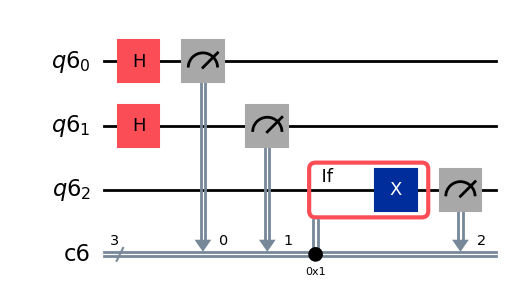

In [8]:
qr = QuantumRegister(3)
cr = ClassicalRegister(3)
qc = QuantumCircuit(qr, cr)
qc.h(qr[0])
qc.h(qr[1])
qc.measure(qr[0], cr[0])
qc.measure(qr[1], cr[1])
with qc.if_test((cr, 0b001)): # If the classical bitstrings are "01" ie first bit 1 and second bit is 0
  qc.x(qr[2])                 # then apply X gate on qubit 2. Remember in Qiskit, we read right to left.
qc.measure(qr[2], cr[2])
qc.draw('mpl')

⏰ Notice that the mesaurement circle is solid if the **if_test** condition bit value is 1

And it will be an outline rather than solid if the **if_test** condition bit valus is 0

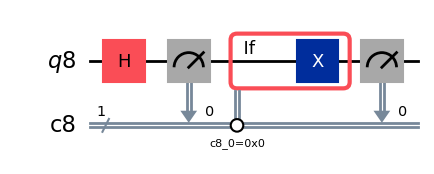

In [10]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit

qr = QuantumRegister(1)
cr = ClassicalRegister(1)
qc = QuantumCircuit(qr, cr)
qc.h(qr[0]) # Applies Hadamard gate
qc.measure(qr[0], cr[0]) # Measure the qubit
with qc.if_test((cr[0], 0)): # If classical bit is 0, then apply X gate
  qc.x(qr[0])
qc.measure(qr[0], cr[0]) # Measure the qubits
qc.draw('mpl')

# Always '1' as output

**Classical Expressions**

How to do real-time classical computation inside a quantum circuit using Qiskit’s dynamic features.<br>
**expr** → tools to build runtime classical logic (like XOR)

*(I beleive it might be helpful if we could dry run the below code for qubits = 6 to increase the understanding)*

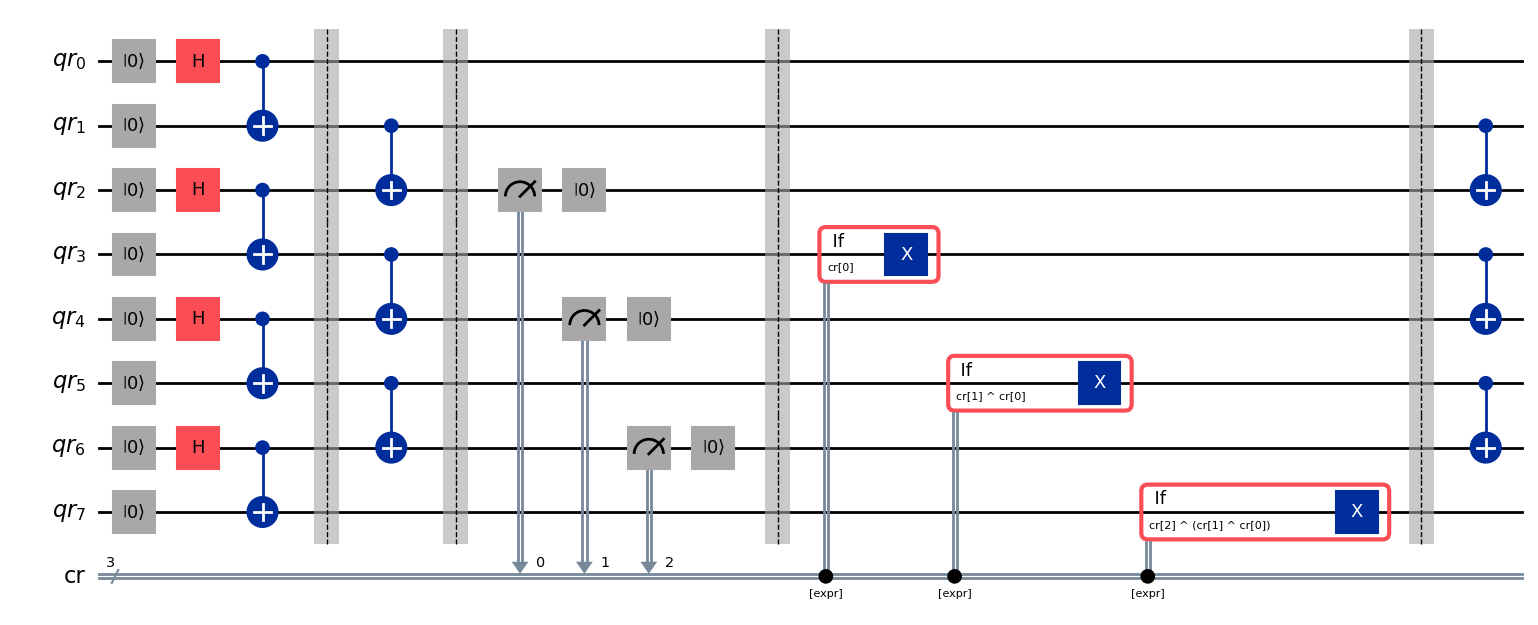

In [10]:
from qiskit import QuantumRegister, QuantumCircuit, ClassicalRegister
from qiskit.circuit.classical import expr

num_qubits = 8
if num_qubits % 2 or num_qubits < 4:
  raise ValueError("num_qubits must be an even integer ≥ 4")

meas_qubits = list(range(2, num_qubits, 2)) # [2, 4, 6] => Measure and reset these qubits

qr = QuantumRegister(num_qubits, "qr") # 8
cr = ClassicalRegister(len(meas_qubits), "cr") # 3
qc = QuantumCircuit(qr, cr)

qc.reset(qr) # Force all qubits to 0
qc.h(qr[::2]) # Apply hadamard to [0, 2, 4, 6]
for i in range(0, num_qubits, 2):
  qc.cx(qr[i], qr[i+1]) # Apply CNOT on (0,1), (2,3), (4,5), (6,7) => Creates Bell pairs
qc.barrier()

for i in range(1, num_qubits-1, 2):
  qc.cx(qr[i], qr[i+1]) # Apply CNOT on (1,2), (3,4), (5,6) => Connecting neighbouring pairs
qc.barrier()

for i, value in enumerate(meas_qubits):
  qc.measure(qr[value], cr[i]) # Measure the qubits
  qc.reset(qr[value]) # Reset the qubits
qc.barrier()

for i in range(num_qubits):
  if i in meas_qubits:
    continue
  left_bits = [k for k, q in enumerate(meas_qubits) if q < i] # Get all the measured values before "ith" qubit
  if not left_bits:
    continue
  parity = expr.lift(cr[left_bits[0]])
  for j in left_bits[1:]:
    parity = expr.bit_xor(cr[j], parity) # Do xor on all the measured values gathered
  with qc.if_test((parity)):
    qc.x(qr[i]) # If xor = 1, apply x gate to the particular "ith" qubit
qc.barrier()

for i in range(1, num_qubits-1, 2):
  qc.cx(qr[i], qr[i+1])

qc.draw("mpl")
